# Mapping Benguela Region (Chlorophyll Concentration)

## Three maps will be produce and one time-series plot along the coat of South Africa (Cape Town coastline)
- A Benguela bathymetry region map
- A map showing the annual mean chlorophyll
- A fix 12 maps showing seasonal variation for each month
- A time-series plot showing two lines, the mean seasonal cycle of the whole region compared with a single grid point

#### Importing libraries

In [2]:
#importing statement
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from matplotlib.colors import LogNorm
import calendar

#### Opening dataset files and reading dataset information

In [3]:
# Chlorophyll dataset (ESA CCI)
ds = xr.open_dataset("C:/Users/zncnqu001/Downloads/ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")
print(ds)
# Bathymetry dataset (GMRT)
bathy = xr.open_dataset("C:/Users/zncnqu001/Downloads/GMRTv4_4_1_20260320topo.grd")

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
  

In [4]:
# Dataset xarrarys
ds

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [5]:
# Dataset information
ds.info()

xarray.Dataset {
dimensions:
	time = 12 ;
	lat = 4320 ;
	lon = 8640 ;

variables:
	int32 crs() ;
		crs:grid_mapping_name = latitude_longitude ;
	float32 chlor_a(time, lat, lon) ;
		chlor_a:standard_name = mass_concentration_of_chlorophyll_a_in_sea_water ;
		chlor_a:long_name = Chlorophyll-a concentration in seawater (not log-transformed), generated by as a blended combination of OCI, OCI2, OC2 and OCx algorithms, depending on water class memberships ;
		chlor_a:units = milligram m-3 ;
		chlor_a:grid_mapping = crs ;
		chlor_a:ancillary_variables = chlor_a_log10_rmsd chlor_a_log10_bias ;
		chlor_a:parameter_vocab_uri = http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU ;
		chlor_a:units_nonstandard = mg m^-3 ;
	datetime64[ns] time(time) ;
		time:standard_name = time ;
		time:axis = T ;
	float64 lon(lon) ;
		lon:standard_name = longitude ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
		lon:axis = X ;
	float64 lat(lat) ;
		lat:standard_name = latitude ;
		lat:long_name = 

In [6]:
# Dataset xarrays variables
ds.data_vars

Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...

In [7]:
# Printing dataset dims
print('Dimensions are stored in a dict-like object:',ds.sizes)
print('The length of the Time dimension is:',ds.sizes['time'])

Dimensions are stored in a dict-like object: Frozen({'time': 12, 'lat': 4320, 'lon': 8640})
The length of the Time dimension is: 12


In [8]:
# visualize the dataset coordinates
ds.coords

Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

In [9]:
# subsetting dataset to benguela region
ds_region = ds.sel(lon=slice(16, 20), lat=slice(-35, -31))

# Subsetting bathymetry(bathy) dataset to the same region
bathy_region = bathy.sel(lon=slice(16, 20), lat=slice(-35, -31))

In [10]:
# Printing bathymetry region dataset
print(bathy_region)

<xarray.Dataset> Size: 2MB
Dimensions:   (lat: 413, lon: 454)
Coordinates:
  * lat       (lat) float64 3kB -34.99 -34.99 -34.98 ... -32.01 -32.0 -32.0
  * lon       (lon) float64 4kB 16.01 16.01 16.02 16.03 ... 19.98 19.98 19.99
Data variables:
    altitude  (lat, lon) float64 2MB ...
Attributes:
    title:        GMRT Grid
    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
    Conventions:  COARDS,CF-1.6
    GMT_version:  4.5.7


In [11]:
# Printing bathymetry data variables
print(bathy_region.data_vars)

Data variables:
    altitude  (lat, lon) float64 2MB ...


### Map 1: A Benguela bathymetry region map
This map will show the Benguela bathymetry region using **PlateCarree projection** and also adding import features such the colour map, contours, gridlines and colour bars. This feature will show a good visulization the Benguela bathymetry along the southwest coast of South Africa.

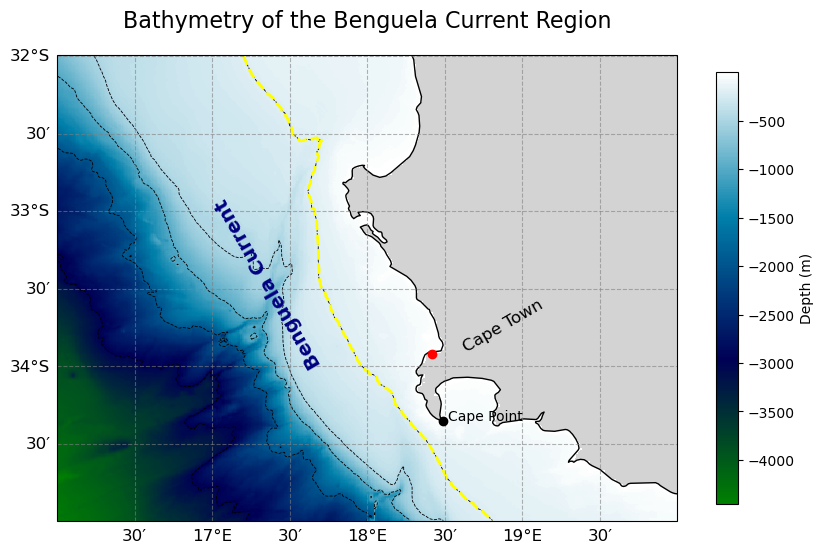

In [12]:
# Setting figure size and plotting bathymetry map
fig = plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Mask land (altitude < 0) to show ocean depth
depth = bathy_region.altitude.where(bathy_region.altitude < 0)

# Plot bathymetry
depth.plot(ax=ax,cmap='ocean',cbar_kwargs={'label': 'Depth (m)','shrink': 0.7})

# Add bathymetry contours (important for shelf & slope)
ax.contour(bathy_region.lon,bathy_region.lat,bathy_region.altitude,levels=[-3000, -2000, -1000, -500, -200],colors='black',linewidths=0.6,transform=ccrs.PlateCarree())

# Highlight continental shelf (-200 m)
ax.contour(bathy_region.lon,bathy_region.lat,bathy_region.altitude,levels=[-200],colors='yellow',linewidths=2,transform=ccrs.PlateCarree())

# Add coastlines and land
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.LAND, facecolor='lightgrey')


# Add gridlines with labels
gl = ax.gridlines(draw_labels=True,dms=True,x_inline=False,y_inline=False,linestyle='--',color='gray',alpha=0.6)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Label Benguela Current
ax.text(17, -34,"Benguela Current",transform=ccrs.PlateCarree(),fontsize=14,color='navy',weight='bold',rotation=120)

# Mark Cape Town
ax.plot(18.42, -33.92,marker='o',color='red',markersize=6,transform=ccrs.PlateCarree())

ax.text(18.6, -33.9,"Cape Town",transform=ccrs.PlateCarree(),fontsize=12,rotation=30)

# Mark Cape Point
ax.plot(18.49, -34.35,marker='o',color='black',transform=ccrs.PlateCarree())

ax.text(18.52, -34.35,"Cape Point",transform=ccrs.PlateCarree(),fontsize=10)

# Add title
ax.set_title("Bathymetry of the Benguela Current Region", fontsize=16, pad=20)

# Save high-quality figure
plt.savefig("Bathymetry_Benguela_Current.png",dpi=300,bbox_inches='tight')

plt.show()

#### Setting data to calculate the annual chlorophyll mean 

In [13]:
# setting dataset to chl_region
chl_region = ds.sel(lon=slice(16,20),lat=slice(-35,-31))

# printing chl_region
print(chl_region)

<xarray.Dataset> Size: 868B
Dimensions:  (time: 12, lat: 0, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 768B 16.02 16.06 16.1 16.15 ... 19.9 19.94 19.98
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 0B ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPE

In [14]:
# Subsetting dataset to benguela_region
benguela_region = ds['chlor_a'].sel(lon=slice(16, 20),lat=slice(-35, -31)) 

#printing benguela_region dataset
print(benguela_region)

<xarray.DataArray 'chlor_a' (time: 12, lat: 0, lon: 96)> Size: 0B
[0 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 768B 16.02 16.06 16.1 16.15 ... 19.9 19.94 19.98
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3


In [15]:
# Calculating the annual mean chlorophyll
annual_mean = ds.chlor_a.mean(dim='time')


In [16]:
annual_mean.dims

('lat', 'lon')

In [17]:
# Printing annual_mean maximum and minimun values
print(annual_mean.min().values, annual_mean.max().values)

0.001 93.51422


### Map 2: Annual Chorophyll mean of the Benguela Region
This Map will plot chorophyll mean concentration, from the coast towards the deeper part of the ocean to determine the climatological value of chorophyll annually. This will be shown using features PlateCarree for mapping, contour lines, color bar logarithimic to determine the color pattern.

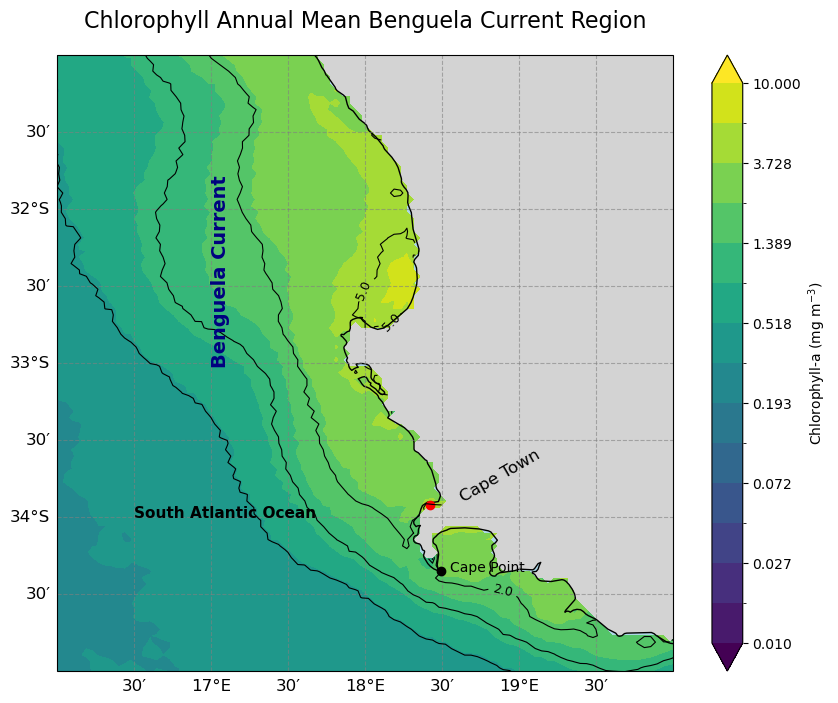

In [18]:
# Fixing figure size and map projection
plt.figure(figsize=(10,8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plotting annual_mean of chlorophyll
annual_mean.plot.contourf(ax=ax,transform=ccrs.PlateCarree(),levels=np.logspace(-2, 1, 15),cmap='viridis',cbar_kwargs={'label': 'Chlorophyll-a (mg m$^{-3}$)'})

# Map extent
ax.set_extent([16, 20, -35, -31], crs=ccrs.PlateCarree())

# Coastlines
ax.coastlines()

# Gridlines
gl = ax.gridlines(draw_labels=True,linestyle='--',color='gray',alpha=0.6,dms=True,x_inline=False,y_inline=False)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}

# Adding label Benguela Current
ax.text(17, -33,"Benguela Current",transform=ccrs.PlateCarree(),fontsize=14,color='navy',weight='bold',rotation=90)

# Adding label Cape Town
ax.plot(18.42, -33.92,marker='o',color='red',markersize=6,transform=ccrs.PlateCarree())

ax.text(18.6, -33.9,"Cape Town",transform=ccrs.PlateCarree(),fontsize=12,rotation=30)

# Adding Cape Point
ax.plot(18.49, -34.35,marker='o',color='black',transform=ccrs.PlateCarree())

ax.text(18.55, -34.35,"Cape Point",transform=ccrs.PlateCarree(),fontsize=10)

# Add borders and land/ocean shading
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Add South Atlantic Ocean label
ax.text(16.5, -34,"South Atlantic Ocean", transform=ccrs.PlateCarree(), fontsize=11,  weight='bold')

# Add chlorophyll contour lines
chl_contours = ax.contour(annual_mean.lon,annual_mean.lat,annual_mean,levels=[0.2, 0.5, 1, 2, 5],colors='black', linewidths=0.8, transform=ccrs.PlateCarree())

# Add contour labels
ax.clabel(chl_contours,inline=True,fontsize=9,fmt='%1.1f')

# Map title
ax.set_title("Chlorophyll Annual Mean Benguela Current Region",fontsize=16,pad=20)

# Save figure (high quality for report)
plt.savefig("Annual_Mean_Chlorophyll_Benguela.png",dpi=300,bbox_inches='tight')

plt.show()

### Setting data to calculate the 12 month seasonal variation mean of chlorophyll

In [19]:
# Printing dataset
print(ds)

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB nan nan nan nan ... nan nan nan nan
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end: 

In [20]:
# Dataset dimensions
ds.dims

FrozenMappingWarningOnValuesAccess({'time': 12, 'lat': 4320, 'lon': 8640})

In [21]:
# Dataset sizes
ds.sizes

Frozen({'time': 12, 'lat': 4320, 'lon': 8640})

In [22]:
# Dataset shapes
ds['chlor_a'].shape

(12, 4320, 8640)

In [23]:
# Setting dataset to data-array
da = ds['chlor_a']

In [24]:
da

<xarray.DataArray 'chlor_a' (time: 12, lat: 4320, lon: 8640)> Size: 2GB
array([[[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       ...,

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]],

       [[nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan],
        ...,
        [nan, nan, ..., nan, nan],
        [nan, nan, ..., nan, nan]]], shape=(12, 4320, 8640), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [25]:
# DataArrays attribution
da.attrs

{'standard_name': 'mass_concentration_of_chlorophyll_a_in_sea_water',
 'long_name': 'Chlorophyll-a concentration in seawater (not log-transformed), generated by as a blended combination of OCI, OCI2, OC2 and OCx algorithms, depending on water class memberships',
 'units': 'milligram m-3',
 'grid_mapping': 'crs',
 'ancillary_variables': 'chlor_a_log10_rmsd chlor_a_log10_bias',
 'parameter_vocab_uri': 'http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU',
 'units_nonstandard': 'mg m^-3'}

In [26]:
#showing DataArrays shapes and dimensions
da.shape, da.dims

((12, 4320, 8640), ('time', 'lat', 'lon'))

In [27]:
# Setting mean of DataArray of time dimension
da_mean = da.mean(dim='time')
da_mean.shape, da_mean.dims

((4320, 8640), ('lat', 'lon'))

In [28]:
# setting anomalies by subtracting the mean field from the original data
anom = da - da_mean
anom

<xarray.DataArray 'chlor_a' (time: 12, lat: 4320, lon: 8640)> Size: 2GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 4320, 8640), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0

In [29]:
# Monthly grouping (i need to confirm this)
ds.groupby('time.month')

<DatasetGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

In [30]:
# Grouping by season of the week groups
ds.groupby('time.season')

<DatasetGroupBy, grouped over 1 grouper(s), 4 groups in total:
    'season': UniqueGrouper('season'), 4/4 groups with labels 'DJF', 'JJA', 'MAM', 'SON'>

In [31]:
# Grouping the dataset by month and take the mean for each month
Monthly_mean = da.groupby('time.month').mean('time')

In [32]:
seasonal_mean = Monthly_mean.reindex(season=['DJF', 'JJA', 'MAM', 'SON'])
seasonal_mean

<xarray.DataArray 'chlor_a' (month: 12, lat: 4320, lon: 8640)> Size: 2GB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 4320, 8640), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [33]:
print(chl_region)
print(chl_region.count())

<xarray.Dataset> Size: 868B
Dimensions:  (time: 12, lat: 0, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 0B 
  * lon      (lon) float64 768B 16.02 16.06 16.1 16.15 ... 19.9 19.94 19.98
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 0B ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPE

In [34]:
# Slicing chl_region
chl_region = ds.sel(lon=slice(10, 20),lat=slice(-31, -35))  
print(chl_region)

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 12, lat: 96, lon: 240)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 768B -31.02 -31.06 -31.1 ... -34.9 -34.94 -34.98
  * lon      (lon) float64 2kB 10.02 10.06 10.1 10.15 ... 19.85 19.9 19.94 19.98
Data variables:
    crs      int32 4B 1
    chlor_a  (time, lat, lon) float32 1MB 0.08524 0.08524 0.08562 ... 0.42 0.379
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:

In [35]:
monthly_mean = chl_region['chlor_a'].groupby('time.month').mean('time')
print(monthly_mean)

<xarray.DataArray 'chlor_a' (month: 12, lat: 96, lon: 240)> Size: 1MB
array([[[0.08524371, 0.08524371, 0.08561585, ...,        nan,
                nan,        nan],
        [0.08437892, 0.08628053, 0.08350191, ...,        nan,
                nan,        nan],
        [0.08234017, 0.08377166, 0.08495805, ...,        nan,
                nan,        nan],
        ...,
        [0.12274022, 0.11804551, 0.11804551, ..., 1.2495366 ,
         0.99922234, 0.8707213 ],
        [0.12137087, 0.12366331, 0.11853237, ..., 0.85762304,
         0.7099083 , 0.6002656 ],
        [0.11782871, 0.12203708, 0.12402025, ..., 0.55229896,
         0.46850914, 0.37887314]],

       [[0.08694588, 0.08694588, 0.087231  , ...,        nan,
                nan,        nan],
        [0.08693913, 0.08843695, 0.08555953, ...,        nan,
                nan,        nan],
        [0.0854525 , 0.08610788, 0.08653415, ...,        nan,
                nan,        nan],
...
        [0.2689461 , 0.2669822 , 0.2669822 , ..

In [36]:
print(chl_region['chlor_a'].min().values, chl_region['chlor_a'].max().values)

0.08015803 20.567156


### Map 3: Chlorophyll monthly mean showing seasonal variation 

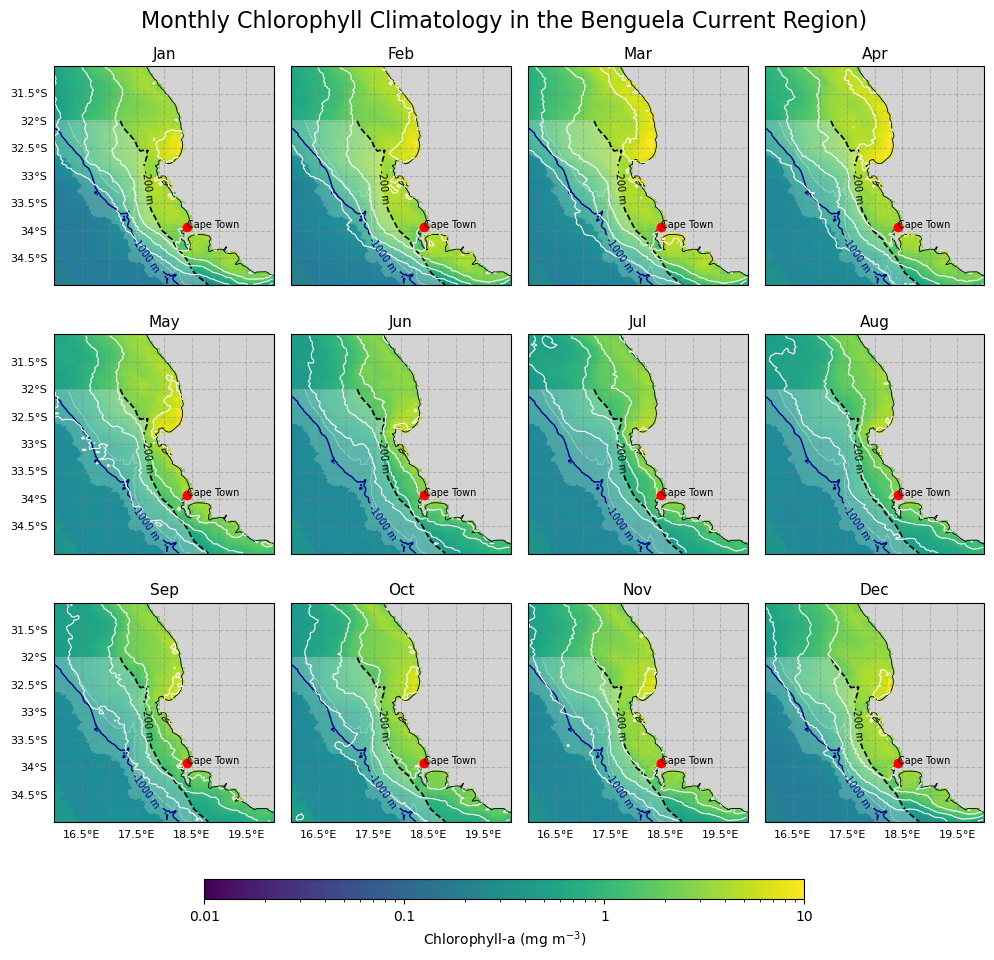

In [37]:
# Setting figure plots
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Plot each month and adding oceanography-specific colormap
for i, ax in enumerate(axes):
    im = monthly_mean.sel(month=i+1).plot(ax=ax,transform=ccrs.PlateCarree(),cmap="viridis",norm=LogNorm(vmin=0.01, vmax=10),add_colorbar=False)
    
    # Coastlines and land
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    # Fix extent so plots start at -31° latitude
    ax.set_extent([16, 20, -35, -31], crs=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False
    if i % 4 != 0: gl.left_labels = False
    if i < 8: gl.bottom_labels = False
    gl.xlabel_style = {'size':8}
    gl.ylabel_style = {'size':8}
    
    # Bathymetry shading
    ax.contourf(bathy_region['lon'].values,bathy_region['lat'].values,bathy_region['altitude'].values,levels=[-4000,-2000,-1000,-500,-200],cmap='Blues_r',alpha=0.3,transform=ccrs.PlateCarree())

    # Shelf (-200 m dashed) and slope (-1000 m solid)
    cs = ax.contour(bathy_region['lon'].values,bathy_region['lat'].values,bathy_region['altitude'].values,levels=[-1000,-200],colors=['darkblue','black'],linewidths=[1,1.2],linestyles=['-','--'],transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt='%d m', fontsize=7)  # add labels to contours

    # Chlorophyll isolines
    chl_data = monthly_mean.isel(month=i)
    ax.contour(chl_data['lon'].values,chl_data['lat'].values,chl_data.values,levels=[0.5,1,2,5],colors='white',linewidths=0.8,transform=ccrs.PlateCarree())

    # Month titles
    ax.set_title(calendar.month_abbr[i+1], fontsize=11)

    # Reference point (Cape Town)
    ax.plot(18.42, -33.93, marker='o', color='red', transform=ccrs.PlateCarree())
    ax.text(18.42, -33.93, "Cape Town", fontsize=7, transform=ccrs.PlateCarree())

#  Adding a single horizontal colorbar
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Chlorophyll-a (mg m$^{-3}$)')
cbar.set_ticks([0.01,0.1,1,10])
cbar.set_ticklabels(['0.01','0.1','1','10'])

# Adding overall title and layout
plt.suptitle("Monthly Chlorophyll Climatology in the Benguela Current Region)",fontsize=16, y=0.97)
plt.subplots_adjust(top=0.92, wspace=0.08, hspace=0.15, bottom=0.15)

# Save figure
plt.savefig("Monthly_Chlorophyll_Benguela.png", dpi=300, bbox_inches='tight')

plt.show()


### Setting dataset to calculate times-series plot

In [136]:
# Setting regional mean dimensions
regional_mean = chl_region.mean(dim=['lat','lon'])
print(regional_mean)

<xarray.Dataset> Size: 152B
Dimensions:  (time: 12)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
Data variables:
    crs      float64 8B 1.0
    chlor_a  (time) float32 48B 0.5816 0.6407 0.728 ... 0.6042 0.5876 0.534


In [143]:
# Compute regional mean seasonal cycle
regional_cycle = regional_mean.groupby('time.month').mean('time')
print(regional_cycle)

<xarray.Dataset> Size: 240B
Dimensions:  (month: 12)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    crs      (month) float64 96B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    chlor_a  (month) float32 48B 0.5816 0.6407 0.728 ... 0.6042 0.5876 0.534


In [144]:
point_cycle = chl_region.sel(lon=16, lat=-32, method='nearest')
print(point_cycle)

<xarray.Dataset> Size: 164B
Dimensions:  (time: 12)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
    lon      float64 8B 16.02
    lat      float64 8B -32.02
Data variables:
    crs      int32 4B 1
    chlor_a  (time) float32 48B 0.4756 0.6611 0.8109 ... 0.3857 0.4546 0.3992
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    N

In [145]:
point_cycle = point.groupby('time.month').mean('time')
print(point_cycle)

<xarray.Dataset> Size: 256B
Dimensions:  (month: 12)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    lon      float64 8B 16.02
    lat      float64 8B -32.02
Data variables:
    crs      (month) float64 96B 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0 1.0
    chlor_a  (month) float32 48B 0.4756 0.6611 0.8109 ... 0.3857 0.4546 0.3992
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI

### Time- series plot 

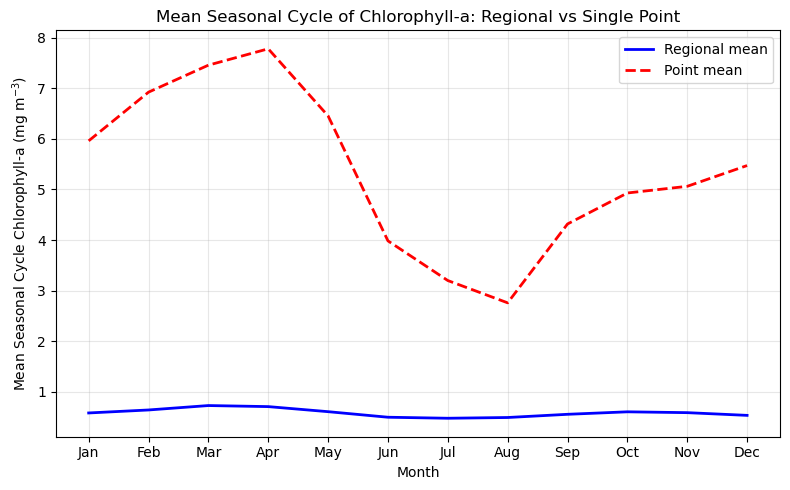

In [158]:
# Plot the seasonal cycles and setting figure size
plt.figure(figsize=(8,5))

# Setting monthly names
months = regional_mean['month'].values
month_names = [calendar.month_abbr[m] for m in months]

# Regional mean line
plt.plot(months, regional_mean['chlor_a'].values, 
         label='Regional mean', linewidth=2, color='blue')

# Single point line
plt.plot(months, point_mean['chlor_a'].values,
         label='Point mean', linewidth=2, linestyle='--', color='red')

# Labels and title
plt.xlabel('Month')
plt.ylabel('Mean Seasonal Cycle Chlorophyll-a (mg m$^{-3}$)')
plt.title('Mean Seasonal Cycle of Chlorophyll-a: Regional vs Single Point')
plt.xticks(months, month_names)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# Save figure as high-quality PNG
plt.savefig("Mean_Seasonal_Cycle_Chlorophyll.png", dpi=300, bbox_inches='tight')
plt.show()